In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import celltrip


# Styling
mpl.rcParams['pdf.fonttype'] = mpl.rcParams['ps.fonttype'] = 42
sns.set_theme(context='paper', style='dark', palette='colorblind')

# Load Data and Policy

In [3]:
# Read data
adatas = [
    celltrip.utility.processing.merge_adatas(
        *celltrip.utility.processing.read_adatas(*[
            f's3://nkalafut-celltrip/Flysta3D/{p}_{m}.h5ad'
            for p in ('E14-16h_a', 'E16-18h_a', 'L1_a', 'L2_a', 'L3_b')
        ], backed=True), backed=True)
    for m in ('expression', 'spatial')]

In [4]:
# Load manager
prefix, training_step = 's3://nkalafut-celltrip/checkpoints/flysta-250909-4', 800
manager = celltrip.manager.BasicManager(
    policy_fname=f'{prefix}-{training_step:04}.weights',
    preprocessing_fname=f'{prefix}.pre',
    mask_fname=f'{prefix}.mask',
    device='cuda')

# Timepoint Interpolation

In [5]:
# Get L1_a and L3_b
sample_num = 1_000  # TODO: Use `celltrip.utility.processing.generate_pseudocells` instead of random sampling
np.random.seed(42)
start_idx = np.random.choice(
    np.where(adatas[0].obs['development'] == 'L1_a')[0], sample_num, replace=False)
start_modalities = [adata[start_idx] for adata in adatas]
end_idx = np.random.choice(
    np.where(adatas[0].obs['development'] == 'L3_b')[0], sample_num, replace=False)
end_modalities = [adata[end_idx] for adata in adatas]

In [10]:
# Simulate start state
manager.set_modalities(start_modalities[:1])
manager.reset_env()
manager.simulate();

100%|██████████| 5120/5120 [00:13<00:00, 368.88it/s]


In [ ]:
# Simulate from steady start to terminal state
# NOTE: Longer simulations may dilute the mapping and spread out transition time,
#       which is a problem to be solved in the future
manager.set_modalities(end_modalities[:1])
time, states = manager.simulate(time=128., skip_time=.1, impute=False, include_vel=True);

100%|██████████| 1280/1280 [00:03<00:00, 355.10it/s]


# Perform Mapping

In [12]:
# Compute velocity density
vel_density = states[..., manager.dim:].mean(dim=-1)  # We take the mean since velocities in the env space are not normalized
vel_density = vel_density.mean(dim=-1)  # Compute mean over all cells for more accurate density estimation
cum_vel_density = vel_density.cumsum(dim=0)  # Get cumulative velocity densities
cum_vel_density = cum_vel_density / cum_vel_density[-1]  # Normalize by summed velocities
start_val, end_val = 2, 4  # L1_a and L3_b are the 2nd and 4th time points in the dataset, respectively
mapped_time = start_val + (end_val - start_val) * cum_vel_density  # Map to biological timepoints

# Utility function for mapping time to velocity density
def map_time(q_time, mapped_time, sim_time, vel_density=None):
    # q_time is the biological time we want to find
    idx = np.searchsorted(mapped_time, q_time)

    # Append beginning on mapped time with duplicate of first value
    mapped_time_pad = np.concatenate([mapped_time[[0]], mapped_time, mapped_time[[-1]]], axis=0)
    sim_time_pad = np.concatenate([sim_time[[0]], sim_time, sim_time[[-1]]], axis=0)
    if vel_density is not None:
        vel_density_pad = np.concatenate([vel_density[[0]], vel_density, vel_density[[-1]]], axis=0)

    # Interpolate between two nearest time points
    b0, b1 = mapped_time_pad[idx], mapped_time_pad[idx+1]
    s0, s1 = sim_time_pad[idx], sim_time_pad[idx+1]
    b1[b1 == b0] += 1  # Avoid division by zero
    interp = lambda p0, p1: ((q_time - b0) * p0 + (b1 - q_time) * p1) / (b1 - b0)

    if vel_density is not None:
        return interp(s0, s1), interp(vel_density_pad[idx], vel_density_pad[idx+1])
    return interp(s0, s1)

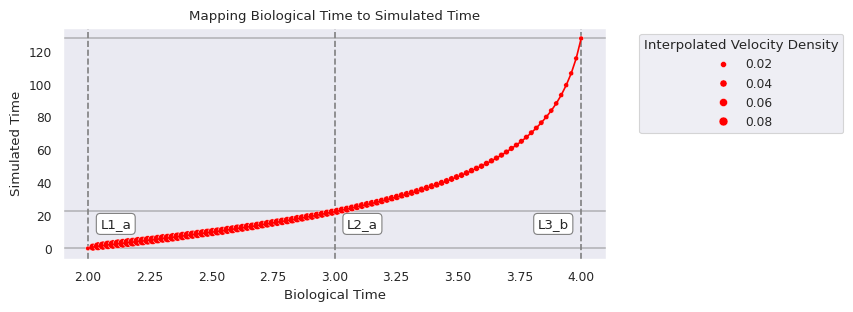

In [41]:
# Get bio-sim times
bio_time = np.linspace(2, 4, 100)
sim_time, sim_vel_density = map_time(bio_time, mapped_time, time, vel_density=vel_density)

# Plot time mapping
fig, ax = plt.subplots(figsize=(7, 3))
df = pd.DataFrame({
    'Biological Time': bio_time,
    'Simulated Time': sim_time,
    'Interpolated Velocity Density': sim_vel_density})
sns.lineplot(
    data=df,
    x='Biological Time',
    y='Simulated Time',
    color='red',
    alpha=1.,
    ax=ax)
sns.scatterplot(
    data=df,
    x='Biological Time',
    y='Simulated Time',
    size='Interpolated Velocity Density',
    color='red',
    alpha=1.,
    ax=ax)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1.05, 1))
ax.set_title('Mapping Biological Time to Simulated Time')

# Draw horizontal lines at intersections with known timepoints
for i in np.searchsorted(bio_time, [2, 3, 4]):
    ax.axhline(
        sim_time[i if i < len(sim_time) else -1],
        linestyle='-',
        color='gray',
        alpha=.5,
        zorder=-1)

# Annotate
margin, height = .05, df['Simulated Time'].max() * .1
ax.axvline(2, color='gray', linestyle='--', zorder=-1)
ax.annotate('L1_a', xy=(2+margin, height), bbox=dict(boxstyle='round', fc='white', ec='gray'))
ax.axvline(3, color='gray', linestyle='--', zorder=-1)
ax.annotate('L2_a', xy=(3+margin, height), bbox=dict(boxstyle='round', fc='white', ec='gray'))
ax.axvline(4, color='gray', linestyle='--', zorder=-1)
ax.annotate('L3_b', xy=(4-margin, height), bbox=dict(boxstyle='round', fc='white', ec='gray'), ha='right');